# Analysis of Automotive Test Data

This notebook combines SQL + Python using DuckDB.


In [1]:
import os

os.listdir("..")


['.venv',
 'automotive.duckdb',
 'data',
 'my_database.duckdb',
 'notebooks',
 'queries',
 'README.md',
 'schema',
 'sql']

In [2]:
import duckdb


In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the DuckDB database file
con = duckdb.connect(r"C:\Users\monta\Documents\Development\GitHub\process-data-sql-lab-main\process-data-sql-lab-main\my_database.duckdb")
con.execute("SHOW TABLES").df()



,name
0,anomalies
1,components
2,sensor_readings
3,test_runs
4,vehicles


In [7]:
con.sql("DESCRIBE sensor_readings").df()


,column_name,column_type,null,key,default,extra
0,reading_id,INTEGER,YES,None,None,None
1,test_run_id,INTEGER,YES,None,None,None
2,timestamp,TIMESTAMP,YES,None,None,None
3,sensor_type,VARCHAR,YES,None,None,None
4,value,FLOAT,YES,None,None,None


In [8]:
con.sql("SELECT * FROM sensor_readings LIMIT 10").df()


,reading_id,test_run_id,timestamp,sensor_type,value
0,1,1,2023-01-10 08:00:01,temperature,18.700001
1,2,1,2023-01-10 08:00:03,voltage,398.200012
2,3,1,2023-01-10 08:00:05,current,112.400002
3,4,1,2023-01-10 08:00:07,vibration,0.320000
4,5,1,2023-01-10 08:00:09,temperature,18.799999
5,6,1,2023-01-10 08:00:11,voltage,397.899994
6,7,1,2023-01-10 08:00:13,current,113.099998
7,8,1,2023-01-10 08:00:15,vibration,0.350000
8,9,1,2023-01-10 08:00:17,temperature,18.900000
9,10,1,2023-01-10 08:00:19,voltage,398.000000


In [9]:
df = con.sql("""
    SELECT timestamp, value
    FROM sensor_readings
    WHERE sensor_type = 'temperature'
""").df()


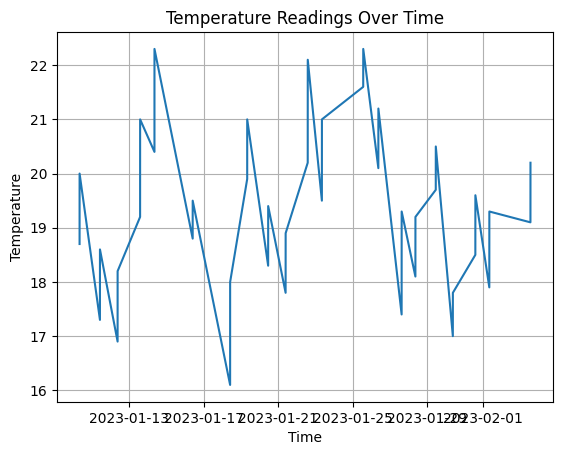

In [10]:
df = con.sql("""
    SELECT timestamp, value
    FROM sensor_readings
    WHERE sensor_type = 'temperature'
    ORDER BY timestamp
""").df()

plt.plot(df["timestamp"], df["value"])
plt.title("Temperature Readings Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()
